In [275]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [277]:
data = pd.read_csv('IMDb Movies India.csv', encoding='latin-1')
data.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [279]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


## data cleaning

In [256]:
data.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [258]:
data.duplicated().sum()

6

In [260]:
data.dropna(inplace=True)
data.drop_duplicates(inplace=True)
data.shape

(5659, 10)

In [262]:
data.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [264]:
data.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='object')

In [266]:
data

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,(2012),82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
...,...,...,...,...,...,...,...,...,...,...
15493,Zubaan,(2015),115 min,Drama,6.1,408,Mozez Singh,Vicky Kaushal,Sarah Jane Dias,Raaghavv Chanana
15494,Zubeidaa,(2001),153 min,"Biography, Drama, History",6.2,"1,496",Shyam Benegal,Karisma Kapoor,Rekha,Manoj Bajpayee
15503,Zulm Ki Zanjeer,(1989),125 min,"Action, Crime, Drama",5.8,44,S.P. Muthuraman,Chiranjeevi,Jayamalini,Rajinikanth
15505,Zulmi,(1999),129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani


## data preprocessing

In [269]:
data['Year']= data['Year'].str.replace(r'[()]','', regex=True).astype(int)

In [271]:
data['Duration']=pd.to_numeric(data['Duration'].str.replace(' min', ''))

In [273]:
data['Votes']=pd.to_numeric(data['Votes'].str.replace(',', ''))

In [61]:
data

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019,109,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,2019,110,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,1997,147,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,2005,142,"Drama, Romance, War",7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,2012,82,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia
...,...,...,...,...,...,...,...,...,...,...
15493,Zubaan,2015,115,Drama,6.1,408,Mozez Singh,Vicky Kaushal,Sarah Jane Dias,Raaghavv Chanana
15494,Zubeidaa,2001,153,"Biography, Drama, History",6.2,1496,Shyam Benegal,Karisma Kapoor,Rekha,Manoj Bajpayee
15503,Zulm Ki Zanjeer,1989,125,"Action, Crime, Drama",5.8,44,S.P. Muthuraman,Chiranjeevi,Jayamalini,Rajinikanth
15505,Zulmi,1999,129,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani


In [63]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5659 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      5659 non-null   object 
 1   Year      5659 non-null   int32  
 2   Duration  5659 non-null   int64  
 3   Genre     5659 non-null   object 
 4   Rating    5659 non-null   float64
 5   Votes     5659 non-null   int64  
 6   Director  5659 non-null   object 
 7   Actor 1   5659 non-null   object 
 8   Actor 2   5659 non-null   object 
 9   Actor 3   5659 non-null   object 
dtypes: float64(1), int32(1), int64(2), object(6)
memory usage: 464.2+ KB


## data visualization

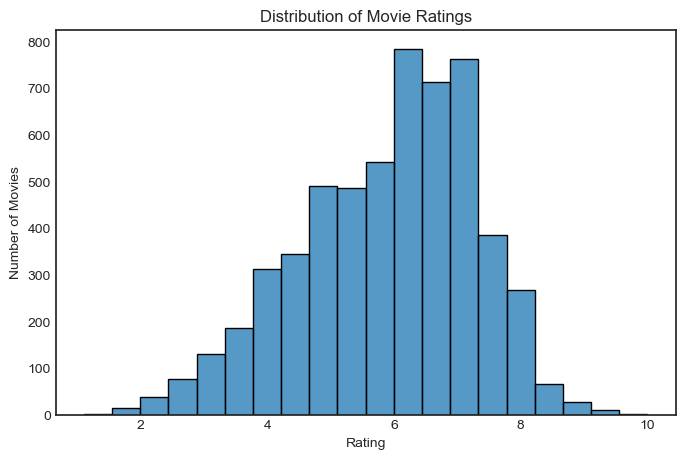

In [125]:
plt.figure(figsize=(8,5))
sns.histplot(data['Rating'], bins=20)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

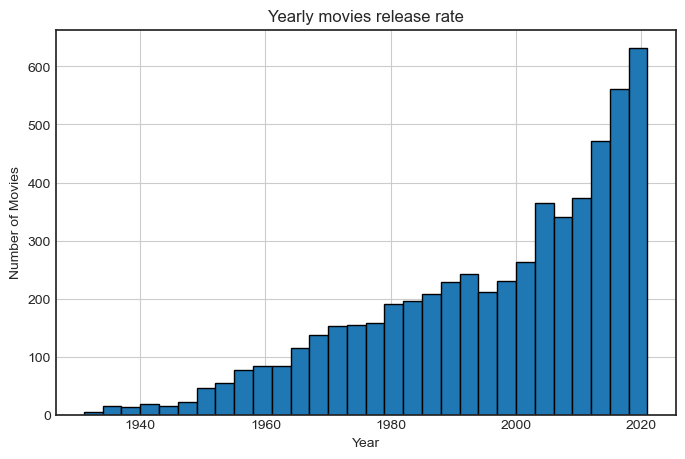

In [117]:
data[['Year']].hist(bins=30, edgecolor='black',figsize=(8,5))
plt.title('early movies release rate')
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

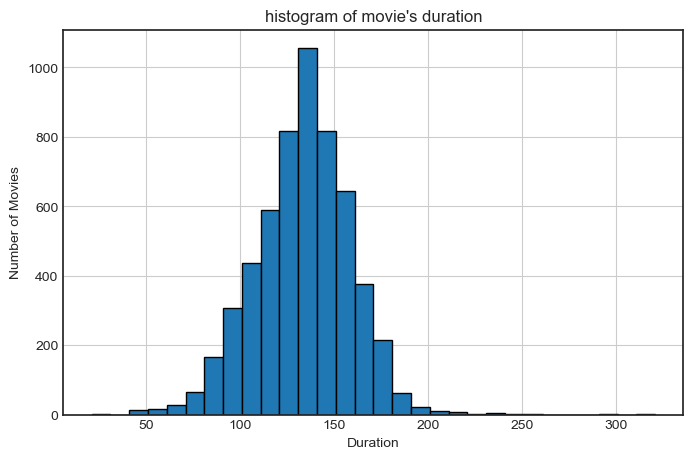

In [146]:
data[['Duration']].hist(bins=30, edgecolor='black',figsize=(8,5))
plt.title('histogram of movie\'s duration')
plt.xlabel("Duration")
plt.ylabel("Number of Movies")
plt.show

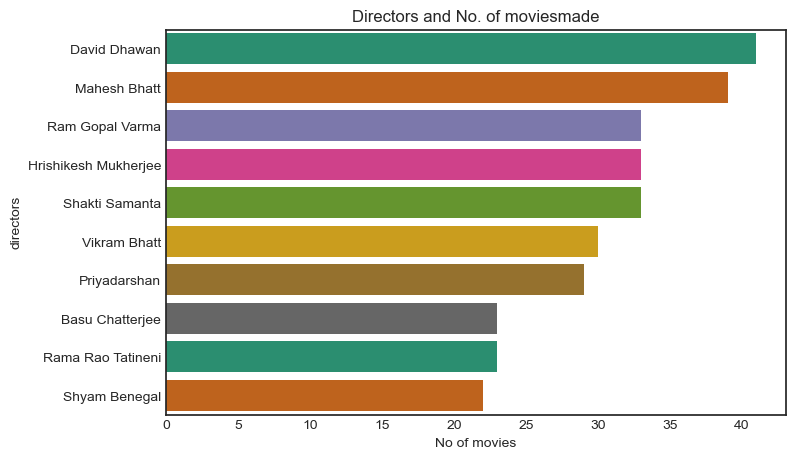

In [149]:
directors=data['Director'].value_counts(ascending=False).head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=directors.values, y=directors.index, palette='Dark2', hue=directors.index, legend=False)
plt.title('Directors and No. of moviesmade')
plt.xlabel('No of movies')
plt.ylabel('directors')
plt.show()

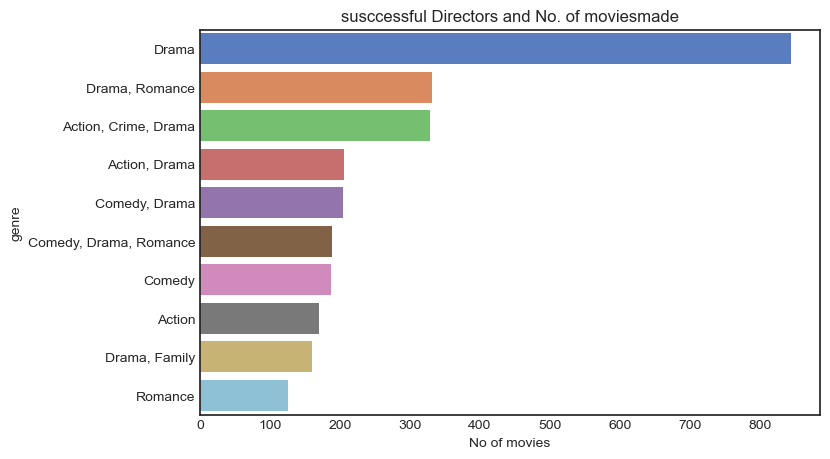

In [151]:
genre=data['Genre'].value_counts(ascending=False).head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=genre.values, y=genre.index, palette='muted', hue=genre.index, legend=False)
plt.title('susccessful Directors and No. of moviesmade')
plt.xlabel('No of movies')
plt.ylabel('genre')
plt.show()

In [153]:
combined_actors = pd.concat([data['Actor 1'],data['Actor 2'],data['Actor 3']])

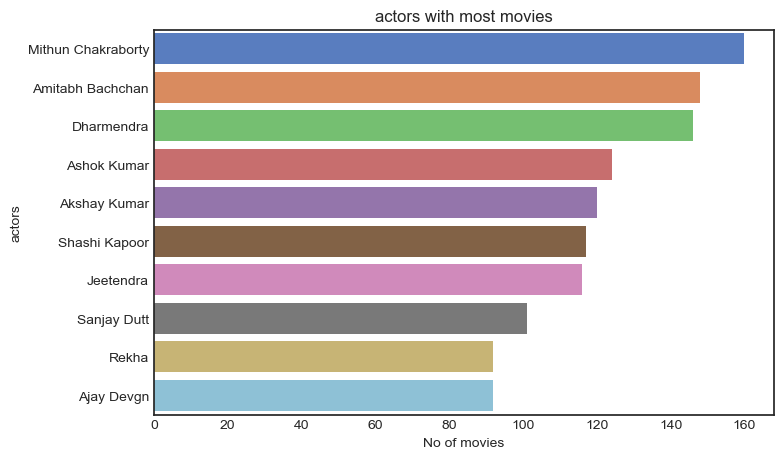

In [157]:
actors= combined_actors.value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=actors.values, y=actors.index, palette='muted', hue=actors.index, legend=False)
plt.title('actors with most movies')
plt.xlabel('No of movies')
plt.ylabel('actors')
plt.show()

In [161]:
avg_rating_per_year=data.groupby('Year')['Rating'].mean().reset_index()
avg_rating_per_year.columns=['Year','Average Rating']

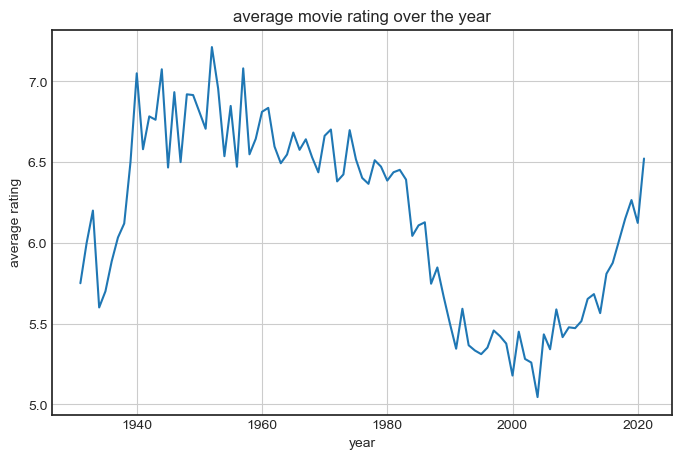

In [202]:
plt.figure(figsize=(8,5))
plt.plot(avg_rating_per_year['Year'],avg_rating_per_year['Average Rating'])
plt.title('average movie rating over the year')
plt.xlabel('year')
plt.ylabel('average rating')
plt.grid(True)
plt.show()

In [208]:
high_rating_movies=data[data['Rating']>8.5]
high_rating_movies

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
967,An Insignificant Man,2016,96,"Documentary, Thriller",8.7,1928,Khushboo Ranka,Vinay Shukla,Arvind Kejriwal,Saurabh Bhardwaj
1314,Ashok Vatika,2018,97,Drama,9.3,7,Rahul Mallick,Kunj Anand,Sanjay Bishnoi,Paras Zutshi
1341,Atal Faisla,2018,127,Drama,8.8,5,Abdul Sattar,Sahil Akhtar,Himayat Ali,Aman Jain
1432,Awasaan,2020,101,Drama,8.7,21,Rajat Kumar Chaturvedi,Arjun Chakrabarty,Trishala Idnani,Sarvagya Jain
1469,B for Bundelkhand,2017,117,Drama,8.8,5,Vishal Mourya,Bharat Chawla,Nemi Chandra Jha,Moumita Nandi
1709,Bahattar Hoorain,2019,120,Comedy,8.8,23,Sanjay Puran Singh Chauhan,Narottam Bain,Aamir Bashir,Pawan Malhotra
1729,Baikunth,2021,72,Family,9.3,29,Vishwa Bhanu,Vishwa Bhanu,Sangam Shukla,Vijay Thakur
2093,Bhagwan Parshuram,1970,136,Drama,8.7,10,Babubhai Mistry,Niranjan Sharma,Shalini,Trilok Kapoor
2437,Black Rose,2020,120,Thriller,8.6,38,Hemant N Mishra,Samiksha Bhatnagar,Rahul Chawla,Abhilash Dada
2709,Chaar Sahibzaade 2: Rise of Banda Singh Bahadur,2016,134,Animation,8.6,656,Harry Baweja,Harman Baweja,Pawan Kalra,Om Puri


In [210]:
rating_counts= high_rating_movies.groupby('Rating')['Name'].count().reset_index()
rating_counts.columns=['Rating','No of movies']
rating_counts=rating_counts.sort_values(by='Rating', ascending=False)
rating_counts

,Rating,No of movies
10,10.0,1
9,9.7,1
8,9.4,3
7,9.3,7
6,9.2,2
5,9.1,4
4,9.0,5
3,8.9,5
2,8.8,6
1,8.7,8


In [218]:
genre_avg_rating=data.groupby('Genre')['Rating'].transform('mean')
data['genre_avg_rating']=genre_avg_rating

director_avg_rating=data.groupby('Director')['Rating'].transform('mean')
data['director_avg_rating']=director_avg_rating

actor1_avg_rating=data.groupby('Actor 1')['Rating'].transform('mean')
data['actor1_avg_rating']=actor1_avg_rating

actor2_avg_rating=data.groupby('Actor 2')['Rating'].transform('mean')
data['actor2_avg_rating']=actor2_avg_rating

actor3_avg_rating=data.groupby('Actor 3')['Rating'].transform('mean')
data['actor3_avg_rating']=actor3_avg_rating

data

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,genre_avg_rating,director_avg_rating,actor1_avg_rating,actor2_avg_rating,actor3_avg_rating
1,#Gadhvi (He thought he was Gandhi),2019,109,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,6.415521,7.000000,6.850000,7.000000,7.000000
3,#Yaaram,2019,110,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,5.716822,4.400000,5.420000,4.400000,4.450000
5,...Aur Pyaar Ho Gaya,1997,147,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,6.242222,5.313333,4.788889,5.786667,5.872727
6,...Yahaan,2005,142,"Drama, Romance, War",7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,6.820000,7.383333,5.435000,6.933333,6.500000
8,?: A Question Mark,2012,82,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,5.477778,5.600000,5.600000,5.883333,5.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15493,Zubaan,2015,115,Drama,6.1,408,Mozez Singh,Vicky Kaushal,Sarah Jane Dias,Raaghavv Chanana,6.415521,6.100000,6.725000,6.100000,5.850000
15494,Zubeidaa,2001,153,"Biography, Drama, History",6.2,1496,Shyam Benegal,Karisma Kapoor,Rekha,Manoj Bajpayee,6.950000,7.250000,4.157143,5.823077,5.954545
15503,Zulm Ki Zanjeer,1989,125,"Action, Crime, Drama",5.8,44,S.P. Muthuraman,Chiranjeevi,Jayamalini,Rajinikanth,5.743465,6.270000,6.307692,5.800000,6.050000
15505,Zulmi,1999,129,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani,5.516505,5.225000,5.481707,4.640000,5.737500


In [220]:
from sklearn.model_selection import train_test_split

In [234]:
x=data[['Year','Votes','Duration','genre_avg_rating','director_avg_rating','actor1_avg_rating','actor2_avg_rating','actor3_avg_rating']]
y=data['Rating']

In [236]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [238]:
train_data=x_train.join(y_train)
train_data

,Year,Votes,Duration,genre_avg_rating,director_avg_rating,actor1_avg_rating,actor2_avg_rating,actor3_avg_rating,Rating
6219,2017,8,135,5.040588,6.950000,7.500000,7.500000,7.500000,7.5
5631,1992,147,159,6.007229,5.600000,5.594340,6.022222,5.498039,5.1
14374,1984,121,159,6.007229,5.625000,5.408989,5.686364,4.800000,5.2
10002,1992,9,132,6.415521,5.692308,4.100000,6.738095,4.811111,3.8
11503,1978,20,133,5.040588,5.733333,6.291358,5.823077,6.564286,5.8
...,...,...,...,...,...,...,...,...,...
11616,1972,22,90,5.725000,5.575000,6.540659,6.814286,6.400000,6.6
11864,1971,204,158,6.449462,7.075000,6.518182,6.525000,6.975000,6.8
10843,1984,6,158,6.416875,5.966667,5.800000,5.800000,5.875000,5.8
9968,1955,16,130,5.522222,6.863636,6.914286,7.346154,6.484615,8.6


In [281]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

x_train= train_data[['Year','Votes','Duration','genre_avg_rating','director_avg_rating','actor1_avg_rating','actor2_avg_rating','actor3_avg_rating']]
y_train = train_data['Rating']
fitted_model_lr=LinearRegression()
fitted_model_lr.fit(x_train,y_train)
y_pred_lr=fitted_model_lr.predict(x_test)

fitted_model_rf=RandomForestRegressor()
fitted_model_rf.fit(x_train,y_train)
y_pred_rf=fitted_model_rf.predict(x_test)

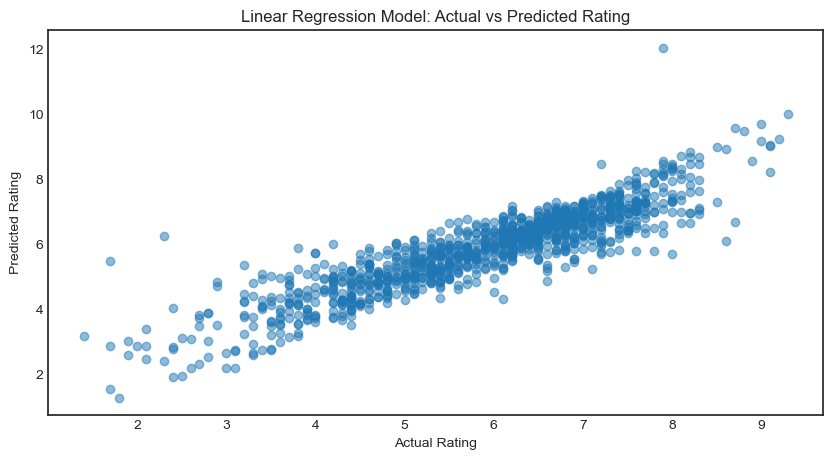

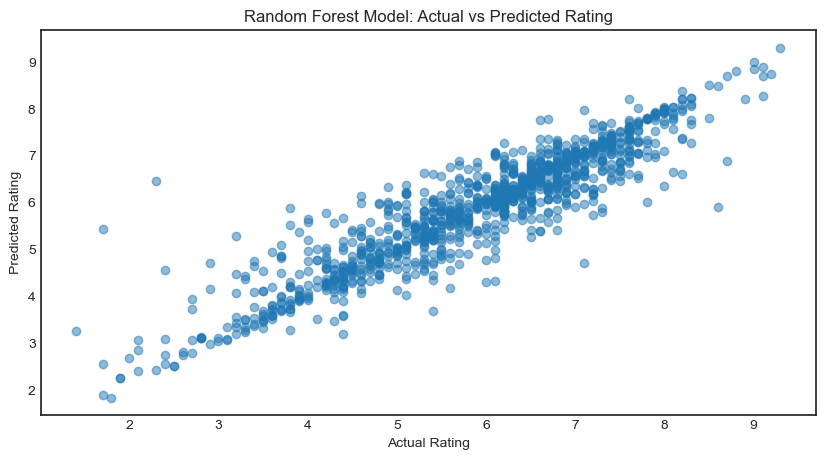

In [291]:
plt.figure(figsize=(10,5))
plt.scatter(y_test,y_pred_lr, alpha=0.5)
plt.title('Linear Regression Model: Actual vs Predicted Rating')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.show()

plt.figure(figsize=(10,5))
plt.scatter(y_test,y_pred_rf, alpha=0.5)
plt.title('Random Forest Model: Actual vs Predicted Rating')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.show()

In [297]:
x

,Year,Votes,Duration,genre_avg_rating,director_avg_rating,actor1_avg_rating,actor2_avg_rating,actor3_avg_rating
1,2019,8,109,6.415521,7.000000,6.850000,7.000000,7.000000
3,2019,35,110,5.716822,4.400000,5.420000,4.400000,4.450000
5,1997,827,147,6.242222,5.313333,4.788889,5.786667,5.872727
6,2005,1086,142,6.820000,7.383333,5.435000,6.933333,6.500000
8,2012,326,82,5.477778,5.600000,5.600000,5.883333,5.600000
...,...,...,...,...,...,...,...,...
15493,2015,408,115,6.415521,6.100000,6.725000,6.100000,5.850000
15494,2001,1496,153,6.950000,7.250000,4.157143,5.823077,5.954545
15503,1989,44,125,5.743465,6.270000,6.307692,5.800000,6.050000
15505,1999,655,129,5.516505,5.225000,5.481707,4.640000,5.737500


In [299]:
y

1        7.0
3        4.4
5        4.7
6        7.4
8        5.6
        ... 
15493    6.1
15494    6.2
15503    5.8
15505    4.5
15508    6.2
Name: Rating, Length: 5659, dtype: float64

In [307]:
data={'Year':[2018], 'Votes':[100], 'Duration':[130], 'genre_avg_rating':[6.0], 'director_avg_rating':[6.5], 'actor1_avg_rating':[7.1], 'actor2_avg_rating':[5.6], 'actor3_avg_rating':[5.9]}
trial_data=pd.DataFrame(data)
predict_rating=fitted_model_rf.predict(trial_data)
print('Predicted rating for trial data: ', predict_rating[0])

Predicted rating for trial data:  6.3599999999999985
